# Кластеризация: применения, DBSCAN, метрики расстояний

Эта статья рассказывает о здаче кластеризации и разных метриках расстояний на примере алгоритма DBSCAN. Для лучшего понимания работы алгоритма и влияния разных метрик вы можете воспользоваться нашим вищуализатором. А для лучшего понимания технических деталей с точки зрения кода посмотрите наш ноутбук.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set(style='whitegrid')

np.random.seed(0)

## 1. Что такое кластеризация?

Представим, что мы учёные, анализирующие результаты какого-то исследования. Например, мы провели опрос среди студентов разных ВУЗов об учебной нагрузке по техническим и гуманитарным предметам (спрашивали о количестве учебных часов, которые занимают пары по этим предметам, в неделю). Для удобства мы отобразили результаты вот на таком графике (каждый студент - это точка с координатами, соответствующими его ответам):

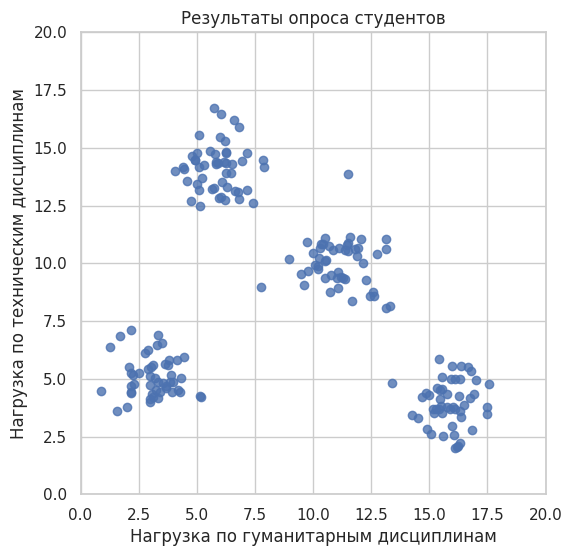

In [ ]:
from sklearn.datasets import make_blobs

X, Y = make_blobs(
    n_samples=200,
    centers=[(16, 4), (6, 14), (11, 10), (3, 5)],
    random_state=42
)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.8)
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.title('Результаты опроса студентов')
plt.xlabel('Нагрузка по гуманитарным дисциплинам')
plt.ylabel('Нагрузка по техническим дисциплинам')
plt.show()

*Здесь и далее точки на графике часто будут нарисованы полупрозрачными, чтобы при их наложении друг на друга наложение было видно за счёт затемнения.*

Видите что-то интересное?

Нетрудно заметить, что график визуально разделяется на 4 "скопления" близких друг к другу точек, то есть студенты образовали 4 группы с похожими ответами:

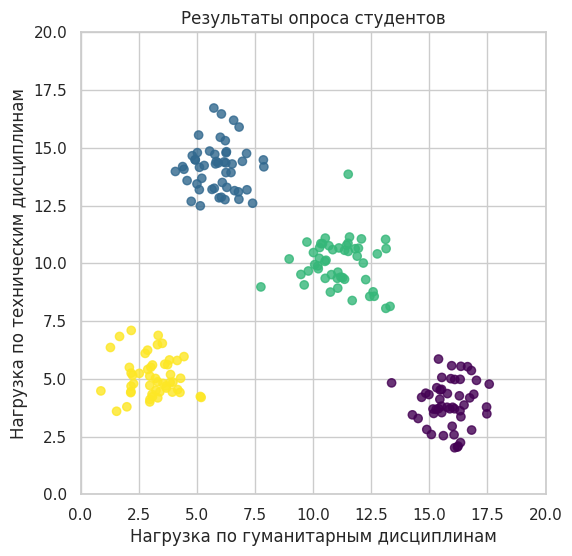

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="viridis", alpha=0.8)
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.title('Результаты опроса студентов')
plt.xlabel('Нагрузка по гуманитарным дисциплинам')
plt.ylabel('Нагрузка по техническим дисциплинам')
plt.show()

Эти группы легко проинтерпретировать:

*   Фиолетовая группа (с самой высокой гуманитарной нагрузкой) - это, очевидно, студенты-гуманитарии (филологи, юристы, историки и т.п.). У них совсем немного технических предметов, обычно это какие-то основы высшей математики или программирования.

*   Синяя группа (с самой высокой технарской нагрузкой) - это студенты-технари (математики, физики, IT-шники), у которых, как правило, 1-2 гуманитарных предмета (история, ОРГ или философия).

*   Зелёная группа (с примерно равной нагрузкой) - это, видимо, студенты-экономисты, которым важно знать как математику, так и гуманитарные (социальные) дисциплины, так как они работают на стыке этих областей (ещё это могут быть аналитики данных в каких-то специфичных областях по типу лингвистики).

*   Жёлтая группа может вызвать удивление, ведь у них низкая нагрузка и по техническим, и по гуманитарным дисциплинам. Но это просто студенты-медики (или биологи, географы, экологи), у которых много естественно-научных дисциплин, занимающих почти всё время.

К чему это было? Разбив студентов на группы похожих, мы смогли понять, что это за студенты. Теперь, анализируя ответы на другие вопросы (на сколько студент устаёт, работает ли, за какую зарплату и т.п.), мы можем выявить специфику каждой группы. Обратите внимание, что всё это мы сделали просто анализируя график.

Сам процесс разбиения точек на графике на вот такие "скопления" и называется **кластеризацией**, а скопления - это **кластеры**. Нетрудно заметить, что это очень полезное действие. Во-первых, из него вытекают выводы двух предыдущих абзацев. Во-вторых, сразу видно, что мы при подготовке нашего исследования "проморгали" третий тип дисциплин в университете - естественно-научный. В-третьих, видно, что у всех групп есть общая закономерность: *среднее* суммарного числа учебных часов у студентов по всем видам дисциплин примерно одинаково во всех группах. В этом можно убедиться, если мысленно провести прямую с графиком $y = 20 - x$. Если мы учтём всю нагрузку студентов-медиков, для них это тоже должно оказать валидным. В-четвёртых, если мы захотим продолжить исследование и вызвать несколько студентов для более детального опроса, логично позвать представителей всех выявленных групп, чтобы выборка была [репрезентативной](https://ru.wikipedia.org/wiki/%D0%A0%D0%B5%D0%BF%D1%80%D0%B5%D0%B7%D0%B5%D0%BD%D1%82%D0%B0%D1%82%D0%B8%D0%B2%D0%BD%D0%BE%D1%81%D1%82%D1%8C).

Конечно, в нашем примере найти кластеры было несложно, ведь скопления видны невооружённым глазом и между ними большие расстояния (исключение составляет одна зелёная точка, к которой мы вернёмся позже). Да и вообще было бы лучше сразу же спрашивать у студентов на какой образовательной программе они учатся, добавить ещё один вопрос в анкету несложно. Однако в реальном мире задачи выглядят сложнее. Не всегда можно спросить у людей что-то напрямую. К примеру, если мы работаем аналитиком данных в крупном маркетплейсе, нас могут попросить узнать что-то о клиентах только по истории их покупок. Мы можем понятия не иметь, на какие кластеры бьются покупатели и бьются ли вообще (и даже сам покупатель тоже может не знать, как какие-то его характеристики обобщаются с характеристиками других людей). Выяснить это может и быть целью исследования. К тому же, реальные данные обычно выглядят не так тривиально, и кластеризовать их "на глаз" проблематично. Данные могут выглядеть вот так:

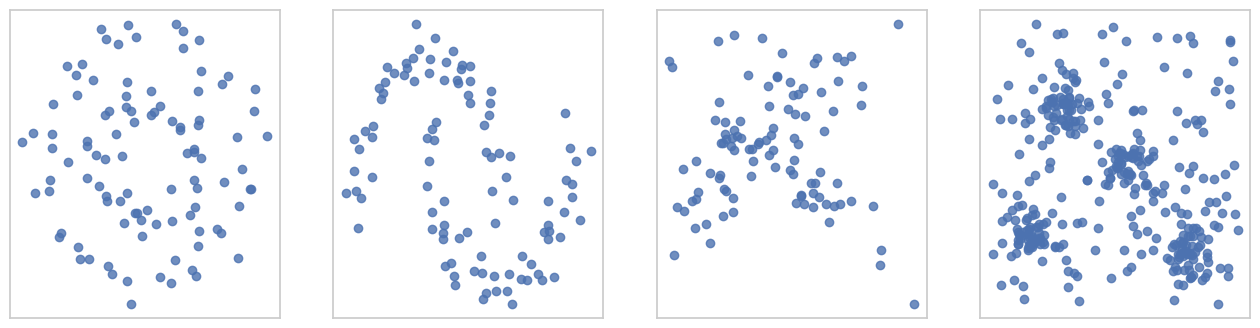

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.1, factor=0.5, random_state=42),
    make_moons(noise=0.1, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0),
    (np.concatenate((X, np.random.uniform(0, 20, (150, 2)))), Y)
]

plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.scatter(x[:, 0], x[:, 1], alpha=0.8)

Уже весьма неприятные данные. Если даже и видно какие-то кластеры, не ясно, как написать код для автоматической кластеризации (руками обрабатывать большие датасеты придётся неимоверно долго), а значит задача кластеризации в общем виде достаточно сложна. Стоило к исходным данным добавить больше разнообразия в виде случайных точек (это называется *шумом*), они стали больше похожи на реальность, но кластеризовать их сложнее (четвёртая картинка выше). Разбиение для остальных картинок можно увидеть ниже. Согласитесь, не совсем очевидно.

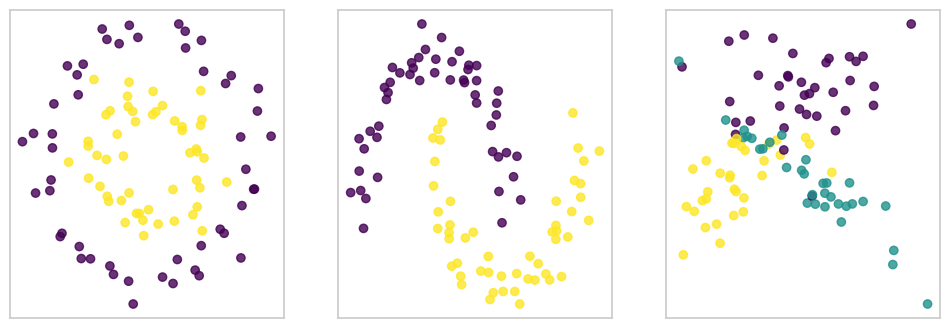

In [ ]:
plt.figure(figsize=(12, 4))
for i, (x, y) in enumerate(datasets[:3]):
    plt.subplot(1, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)

Итак, нужно научиться программно кластеризовать датасеты. Но прежде чем мы перейдём к алгоритму, нужно понять о кластеризации ещё пару вещей...

## 2. Где и как применяется кластеризация?

### Ещё немного о маркетплейсе

Если вы пока сомневаетесь в полезности кластеризации в реальном мире, давайте доразберём пример с маркетплейсом. Когда мы кластеризуем людей (например, на основе возраста и средней цены их покупок за месяц), результат, безусловно, не будет идеальным: кластеры могут получиться слишком общими, большими или маленькими, в данных в принципе может не быть закономерностей. Но наша работа и не сводится к одной лишь кластеризации. Она может стать первым шагом в превращении огромной базы данных во что-то понятное. Например, если мы захотим собрать [фокус-группы](https://ru.wikipedia.org/wiki/%D0%A4%D0%BE%D0%BA%D1%83%D1%81-%D0%B3%D1%80%D1%83%D0%BF%D0%BF%D0%B0) из наших пользователей, с нуля понять, кого и в каких количествах звать (молодёжь, пенсионеров, постоянных покупателей, крупных покупателей...) вообще не ясно. Да, можно отдельно собрать статистику по их возрасту и тратам на нашей платформе, но очевидно, что лучше сразу учитывать взаимосвязь этих характеристики. Подобный подход (попробовать начать работу с незнакомым датасетом с простых шагов) называется **разведывательный анализ данных**.

В рамках маркетплейса применять кластеризацию можно и к товарам. Причём делать это желательно на ежедневной основе (то есть точно не в ручную), ведь на платформе постоянно появляются новые продукты. Если пользователь купил какой-то товар, можно предложить ему в рекомендациях несколько из того же кластера. Если что-то из этого ему приглянётся, мы получим прибыль, а если нет - угадаем с предложением в следующий раз.

### Такси, доставка и расстояния между точками

По законам жанра мы не можем не упомянуть точки на карте. Множество таких точек (адресов и координат) часто приходится обрабатывать для онлайн-карт, вышек связи, сервисов доставки и такси. Понятней всего задача для доставки: будет глупо направлять курьера с двумя заказами на адреса в разных концах города. Лучше выдавать курьеру что-то наподобие своего кластера - набора заказов на соседние адреса. Но такую задачу подробно разобрать здесь будет сложно, так как заказы всё время разные, а распределять их между курьерами нужно постоянно, что требует применения сложной теории графов. Куда проще идея, которая часто используется в сервисах такси: проанализировать историю заказов, чтобы выделить места, куда/откуда чаще всего ездят пассажиры. Обычно это аэропорты и вокзалы. Зная конкретные кластеры, можно заранее направить в эти районы больше машин, а также выбрать, где конкретно лучше подбирать пассажиров (часто это делается в **центре кластера**).

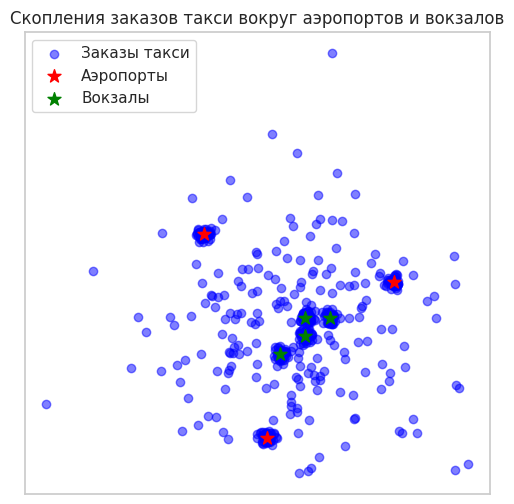

In [ ]:
from sklearn.datasets import make_blobs

airports = [(-7, 8), (8, 4), (-2, -9)]
train_stations = [(3, 1), (1, 1), (1, -0.5), (-1, -2)]
X, y = make_blobs(
    n_samples=[200] + [50] * 7,
    centers=[(0, 0)] + airports + train_stations,
    cluster_std=[6] + [0.3] * 7,
    random_state=42
)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.5, label='Заказы такси')
plt.scatter(*zip(*airports), c='red', marker='*', s=96, label='Аэропорты')
plt.scatter(*zip(*train_stations), c='green', marker='*', s=96, label='Вокзалы')
plt.xticks([])
plt.yticks([])
plt.legend()
plt.title('Скопления заказов такси вокруг аэропортов и вокзалов')
plt.show()

Из таких "географических" примеров становится ясен ответ на вопрос, который возможно уже возник у внимательного читателя: а что значит *похожие объекты*? По какому принципу объединять что-то в кластер? Здесь похожие точки - это близкие точки, то есть точки, расстояние между которыми мало. Расстояние между двумя точками на координатной плоскости вычисляется через теорему Пифагора по формуле:

$$d = \sqrt{Δx^2 + Δy^2} = \sqrt{(x_1-x_2)^2+(y_1-y_2)^2}$$

Где координаты точек это $(x_1, y_1)$ и $(x_2, y_2)$.

Например, расстояния между точками $(1, 2)$, $(3, 5)$ и $(4, 1)$ на рисунке ниже такие:

$d_{12} = \sqrt{(1 - 3)^2+(2 - 5)^2} = \sqrt{4+9} = \sqrt{13} \approx 3.6$

$d_{13} = \sqrt{(1 - 4)^2+(2 - 1)^2} = \sqrt{9+1} = \sqrt{10} \approx 3.16$

$d_{23} = \sqrt{(3 - 4)^2+(5 - 1)^2} = \sqrt{1+16} = \sqrt{17} \approx 4.12$

(Наверное, это и так ясно, но важно понимать, что расстояние между точками $(x_1, y_1)$ и $(x_2, y_2)$ равно расстоянию между $(x_2, y_2)$ и $(x_1, y_1)$. Как говорится, доказательство тривиально и оставляется читателю в качестве несложного упражнения...)

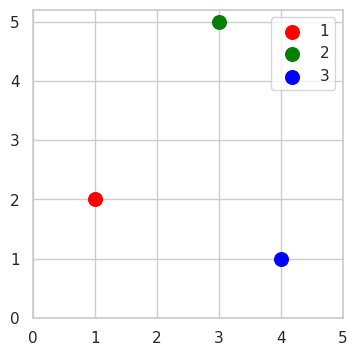

In [ ]:
plt.figure(figsize=(4, 4))
for i, (x, y, c) in enumerate([(1, 2, 'red'), (3, 5, 'green'), (4, 1, 'blue')]):
  plt.scatter(x, y, c=c, s=96, label=str(i + 1))
plt.xticks(range(6))
plt.yticks(range(6))
plt.legend()
plt.show()

Этот же принцип мы будем применять и к остальным данным, просто вычисляя расстояния между точками на графике. У такого подхода (и у расстояний в целом), правда, есть много нюансов, но о них мы поговорим ближе к концу статьи.

### Многомерность

Однако в реальности данные зачастую не ограничиваются двумя параметрами (двумя координатами). Посмотрим на всё тот же опрос студентов, но теперь уже с учётом естественно-научных дисциплин:

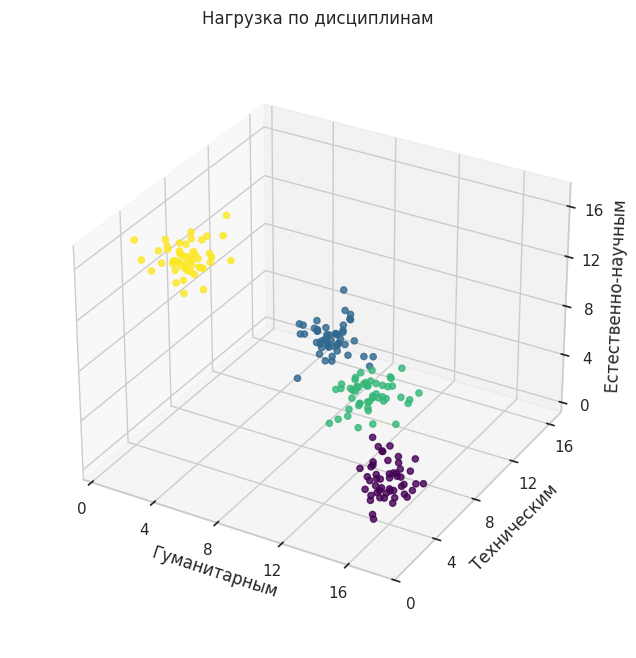

In [ ]:
from sklearn.datasets import make_blobs

X, Y = make_blobs(
    n_samples=200,
    n_features=3,
    centers=[(16, 4, 3), (6, 14, 3), (11, 10, 3), (3, 5, 15)],
    random_state=42
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.9)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=Y, cmap="viridis", alpha=0.8)
ax.set_xlabel('Гуманитарным')
ax.set_ylabel('Техническим')
ax.set_zlabel('Естественно-научным ')
ax.set_xticks(range(0, 20, 4))
ax.set_yticks(range(0, 20, 4))
ax.set_zticks(range(0, 20, 4))
plt.title('Нагрузка по дисциплинам')
plt.show()

Как вы видите, разбираться в трёхмерной картинке уже не очень приятно, даже когда кластеры чётко выделяются. И это они ещё не накладываются друг на друга, перегораживая обзор. При этом просто проигнорировать одну из координат нельзя. Вот что было бы, если бы мы проигнорировали, например, технические дисциплины:

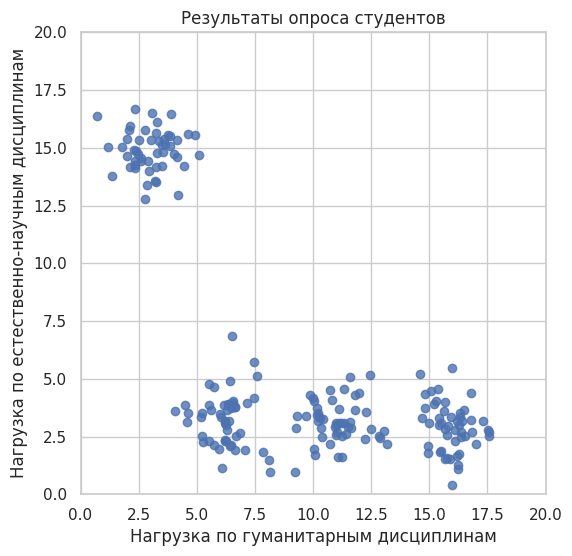

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 2], alpha=0.8)
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.title('Результаты опроса студентов')
plt.xlabel('Нагрузка по гуманитарным дисциплинам')
plt.ylabel('Нагрузка по естественно-научным дисциплинам')
plt.show()

Кластеры выделяются уже не очень хорошо, и это нам ещё повезло (без третей координаты они могли наложиться друг на друга). Значит анализировать данные точно лучше программно. Но как вычислить расстояние между точками в 3D?

Пусть у нас есть точки с координатами $(x_1, y_1, z_1)$ и $(x_2, y_2, z_2)$. Рассмотрим точку с координатами $(x_2, y_2, z_1)$ (две координаты от второй точки, одна от первой). Расстояние между $(x_1, y_1, z_1)$ и $(x_2, y_2, z_1)$, так как они в одной плоскости, это расстояние между точками с координатами $(x_1, y_1)$ и $(x_2, y_2)$ на плоскости, равное $\sqrt{(x_1-x_2)^2+(y_1-y_2)^2}$. Расстояние между $(x_2, y_2, z_2)$ и $(x_2, y_2, z_1)$ равно $|z_1-z_2|$. При этом наши три точки образуют прямоугольный треугольник (это не сложно понять, если посмотреть на $(x_2, y_2, z_1)$ как на проекцию $(x_2, y_2, z_2)$ на "одну высоту" с $(x_1, y_1, z_1)$), катеты которого мы только что нашли. Значит его гипотенуза (то есть как раз расстояние между исходными точками) равна:

$$\sqrt{(\sqrt{(x_1-x_2)^2+(y_1-y_2)^2})^2 + |z_1-z_2|^2} = \sqrt{(x_1-x_2)^2+(y_1-y_2)^2 + (z_1-z_2)^2} = \sqrt{Δx^2 + Δy^2 + Δz^2}$$

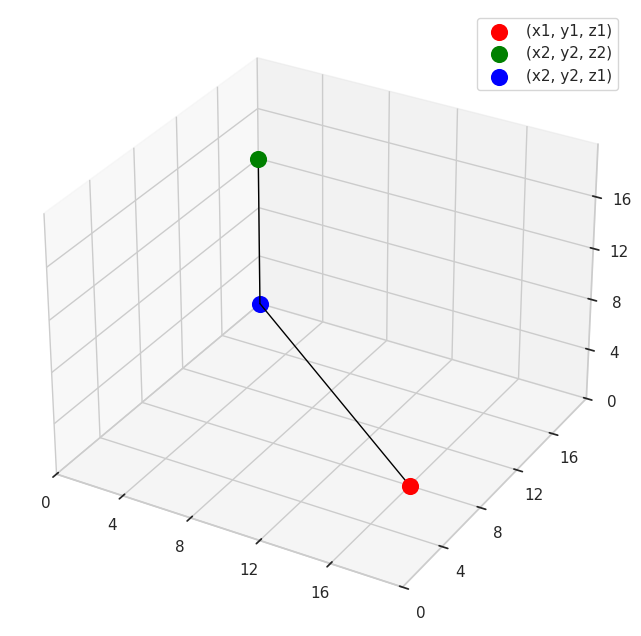

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
ax.plot([16, 0], [8, 20], [0, 0], color='black', linewidth=1)
ax.plot([0, 0], [20, 20], [0, 12], color='black', linewidth=1)
for x, y, z, c, label in [(16, 8, 0, 'red', '(x1, y1, z1)'), (0, 20, 12, 'green', '(x2, y2, z2)'), (0, 20, 0, 'blue', '(x2, y2, z1)')]:
    ax.scatter(x, y, z, c=c, s=128, label=label)
ax.set_xlim(0, 20)
ax.set_ylim(0, 20)
ax.set_zlim(0, 20)
ax.set_xticks(range(0, 20, 4))
ax.set_yticks(range(0, 20, 4))
ax.set_zticks(range(0, 20, 4))
plt.legend()
plt.show()

Легко заметить, что эта формула очень похожа на формулу для двумерного случая и отличается от неё только добавлением $Δz^2$. Аналогично формула обобщается и на многомерный ($n$-мерный) случай: если у нас точки имеют координаты $(x_1, x_2, ..., x_n)$ и $(y_1, y_2, ..., y_n)$, то расстояние между ними равно:

$$\sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + ... + (x_n - y_n)^2}$$

Да, многомерный случай нам понадобится. Вообще говоря, кластеризация происходит именно в таком случае, ведь в современном мире мы обрабатываем большие датасеты со сложными зависимостями, где объекты описываются десятками, а иногда и сотнями параметров. Мы можем анализировать не только нагрузку студентов по часам в неделю, но и время на учебную практику, количество экзаменов, среднюю оценку и т.д. Аналогично на маркетплейсе лучше изучать покупателей по множеству признаков, начиная от возраста, и заканчивая средним временем, проводимом на сайте в неделю. Многомерности не нужно бояться, вся логика маломерных случаев спокойно на неё обобщается, но при этом многомерность позволяет лучше различать кластеры. Все необходимые эффекты мы по прежнему будем стараться иллюстрировать в 2D.

### Кластеризация vs Классификация

Возможно вы уже слышали о другой похожей задаче - **классификации**. Важно понимать отличия между ней и кластеризацией. И классификация, и кластеризация разделяют объекты на группы похожих, но только в классификации эти группы изначально заданы. В классификации мы обучаем модель, определяющую класс объекта, на датасете, где у каждого объекта уже указан его класс. То есть [обучающая выборка](https://ru.wikipedia.org/wiki/%D0%9E%D0%B1%D1%83%D1%87%D0%B0%D1%8E%D1%89%D0%B8%D0%B9,_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BE%D1%87%D0%BD%D1%8B%D0%B9_%D0%B8_%D1%82%D0%B5%D1%81%D1%82%D0%BE%D0%B2%D1%8B%D0%B9_%D0%BD%D0%B0%D0%B1%D0%BE%D1%80%D1%8B_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85) имеет вид $(X_i, y_i)_{i=1}^n$, где $X_i$ - объект, а $y_i$ - его класс. Например, объект может быть студентом ($X_i$ описывает его характеристики), а $y_i$ - образовательной программой, на которой тот обучается. И модель учится на примерах студентов, для которых она знает правильный ответ ($y_i$), предсказывать образовательную программу студентов, для которых она ответ не знает.

В кластеризации же мы никакие $y_i$ не знаем. В обучающей выборке есть только $X_i$. Разбить её на классы (кластеры) модель должна сама, а так как $y_i$, задающих классы, нет, модели придётся придумывать их самой. То есть заранее не определены ни сами кластеры, ни куда какой объект входит. Такой подход (есть $X_i$, но к ним не даны ответы в виде $y_i$) называется **обучением без учителя**. Этот метод незаменим, если у нас новые данные, про закономерности в которых (например, делятся ли объекты на какие-то группы) мы ничего не знаем.

Однако кластеризация может оказаться полезной и для классификации. Например, у нас может быть датасет объектов, для которого известны классы, но какому классу какие объекты принадлежат - неизвестно. Такое случается чаще, чем может показаться, потому что для многих данных получить датасет с разбиением на классы можно только сделав это разбиение вручную (это называется **разметкой данных**). А ведь датасет может состоять из миллиона картинок и для каждой нужно будет указать, что на ней изображено.

Здесь на помощь и приходит кластеризация. Если научиться измерять "похожесть" двух картинок (своего рода расстояние между картинками), можно разбить датасет на кластеры. Далее всё равно придётся ручками их проанализировать, чтобы понять, какому классу (классам) какой кластер соответствует (и соответствует ли), но для этого нужно просмотреть не все кластеры целиком, а только несколько картинок из каждого (лучше пару десятков), что можно сделать легко и быстро. Такой способ далеко не идеален (полезней всё же найти размеченный датасет, так как алгоритмы классификации обычно работают эффективней кластеризации), но для простых классификаций (по картинке понять, какая буква/цифра на ней изображена) вполне подходит. Кластеризовав обучающую выборку, можно классифицировать новые данные, относя каждый объект к ближайшему к нему классу-кластеру. Так что классификацию можно пробовать выполнять за счёт кластеризации. А вот наоборот нельзя, так как без данного заранее разбиения на классы классификация не работет (можно убрать $y_i$ из $(X_i, y_i)_{i=1}^n$, но добавит его, если его не было, нельзя).

## 3. Алгоритм DBSCAN

### Формальная постановка задачи

Итак, наша задача - разбить набор данных $(X_1, X_2, X_3, ... X_n)$ на кластеры так, чтобы в каждом кластере оказались соседние объекты. Каждый объект задаётся координатами в $d$-мерном пространстве: $X_i = (x_{i1}, x_{i2}, ..., x_{id})$ (например, в нашей задаче про студентов $d=3$). Расстояние между объектами $X_i = (x_{i1}, x_{i2}, ..., x_{id})$ и $X_j = (x_{j1}, x_{j2}, ..., x_{jd})$ вычисляется через функцию расстояния (она называется **метрикой**):

$$\rho(X_i, X_j) = \sqrt{\sum_{k=1}^d (x_{ik}-x_{jk})^2} = \sqrt{(x_{i1}-x_{j1})^2 + ... + (x_{id}-x_{jd})^2}$$

Алгоритмов кластеризации невероятно много, у всех у них есть свои преимущества и недостатки. Эта же статья посвящена одному из самых простых (что не делает его плохим) - DBSCAN.

### Идея наивного алгоритма

DBSCAN расшифровывается как Density-Based Spatial Clustering of Applications with Noise (основанная на плотности пространственная кластеризация для приложений с шумами). Не пугайтесь, нам здесь важны только слова *плотность* и *шум*.

Поскольку, как мы уже поняли, соседние точки должны лежать в одном кластере, мы можем строить кластер самым простым способом: возьмём произвольную вершину (точку), найдём ближайшую к ней и объявим их одним кластером. После этого найдём среди оставшихся вершин ближайшую к этим двум (к любой из них) и добавим в тот же кластер. Далее найдём ближайшую к этим трём, затем четырём, пяти... Стоп, но ведь так мы в итоге добавим в один кластер все вершины из датасета! Значит нужно какое-то ограничение.

Будем добавлять новую вершину в кластер только если расстояние от неё до кластера (до ближайшей вершины из кластера) будет не больше некоего числа $𝜀$ (эпсилон), которое мы выберем заранее. Будем называть вершины, расстояние между которыми не превышает $𝜀$, *соседними*. Посмотрим, как формируется кластер без этого ограничения и с ним:

![Справа изображён кластер без огранияения, а слева - с огреничением в 75 пикселей](1.png)

Когда мы сформируем один кластер, можно начать делать другой: выбираем любую вершину, которая вне первого кластера и делаем все те же действия по добавлению её соседей в кластер:

![Три кластера после выполнения алгоритма. Соседние вершнины соеденины отрезками](2.png)

Теперь мы можем формализовать наш алгоритм:

1) Изначально все вершины вне кластеров (назовём их *независимыми*)
2) Выбираем любую независимую вершину. Объявляем её новым кластером
3) Добавляем в текущий кластер ближайшую к нему независимую вершину, если расстояние от неё до кластера не превосходит $𝜀$
4) Делаем пункт 3 пока можем. Если в какой-то момент независимых вершин не осталось, завершаем алгоритм. Если независимые есть, но расстояние до ближайшей вершины оказалось больше $𝜀$, мы считаем текущий кластер сформированным и начинаем пункт 2 заново

В результате мы так или иначе переберём все вершины и каждая попадёт в какой-то кластер. Важно отметить, что мы ищем новые вершины для кластера только среди независимых не потому что не знаем, что делать, если два кластера будут претендовать на одну вершину, а потому что такая ситуация невозможна и новые могут быть только среди не зависимых. Обоснуем. Если в текущем кластере $X$ есть вершина $x$ и нашлась такая **не** независимая вершина $y$ (пусть $y$ принадлежит кластеру $Y$), что $\rho(x, y) < 𝜀$, это значит, что формирование кластера $Y$ не могло быть завершено без добавления вершины $x$, ведь тогда $x$ была независимой и $\rho(y, x) < 𝜀$. Значит $x$ должна была быть добавлена в $Y$. Если распространить это рассуждение на соседей вершины $x$ (а потом и их соседей и т.д.), получится, что кластер $X$ вообще не мог бы появиться, так как все его вершины вошли бы в кластер $Y$ на этапе его формирования. Получаем противоречие. Это доказательство базируется на важном свойстве расстояния (и значит и способности двух вершин быть соседними): $\rho(x, y) = \rho(y, x)$. Применим его, чтобы изменить порядок попадания вершин в кластер на более удобный.

Искать среди всех независимых вершин ближайшую к кластеру не очень удобно с точки зрения кода, поэтому на практике используется подход с [очередью](https://docs-python.ru/standart-library/modul-queue-python/) из вершин. **Очередь** - это структура данных, в которую мы можем класть и вынимать элементы по одному, при чём вынимаются они в том порядке, в котором мы их клали (чем раньше положили, тем раньше достанем - всё как в реальной очереди). Мы будем использовать алгоритм, в котором каждая вершина кластера берётся из начала очереди и добавляет в эту очередь всех своих соседей в радиусе $𝜀$:

1) Изначально все вершины считаются независимыми и не принадлежат никакому кластеру
2) Выбираем любую из независимые вершин и объявляем её новым кластером, кладём эту вершину в очередь
3) Забираем первую вершину из очереди и добавляем в кластер всех её независимых соседей, добавляем их в очередь
4) Если очередь не пуста, выполняем пункт 3 снова
5) Если же очередь пуста, завершаем формирование этого кластера
6) Если есть ещё независимые вершины, начинаем формирование нового кластера с пункта 2. Иначе завершаем алгоритм

![Шаги образования кластера. Все шаги подписаны. Шагом 4 обозначается переход к следующей вершине, а шагом 3 - добавление. Вершины, соседи которых уже добавлены, пропущены](3.png)

Ещё один важный момент. Несложно заметить, что у нас могут получаться кластеры из одной вершины:

![Две точки расположены слишком далеко от других. Они образуют ораньжевый и фиолетовый кластеры. У фиолетовой точки показан радиус поиска соседей. Видно, что он пуст](4.png)

Наверное, это не очень правильно, ведь идея кластеризации заключается в поиске закономерностей через выявление *групп* похожих объектов. Ясно, что могут быть и не похожие ни на кого объекты, но это связано только с тем, что наш мир очень разнообразен. Нет смысла делить всех людей на кластеры по уникальной ДНК, изучать единственное на планете яблоко весом в полкило (кроме как аномалию) или заводить отдельную научную категорию под каждое удачно стечение обстоятельств или исключение из общих правил. Если вспомнить все примеры задач, которые мы разбирали выше, кластеры из одной вершины нигде не были полезными.

Поэтому такие одинокие точки, вокруг которых в радиусе $𝜀$ ничего нет, мы будем помечать как **шум** и не будем относить их ни к одному кластеру. Шумом называют всевозможные выбросы (например, аномально большой/низкий рост) и просто не имеющие закономерность данные (равномерное распределение зарплат среди людей и т.п.). Он есть в практически любых данных, потому что в реальном мире всегда есть случайности, отклонения от нормы и погрешности измерений. Умение отделять шум от кластеров считается сильной стороной алгоритма DBSCAN.

Теперь давайте взглянем на разные $𝜀$ (рекомендуется поэксперементировать с разными значениями в нашем визуализаторе):



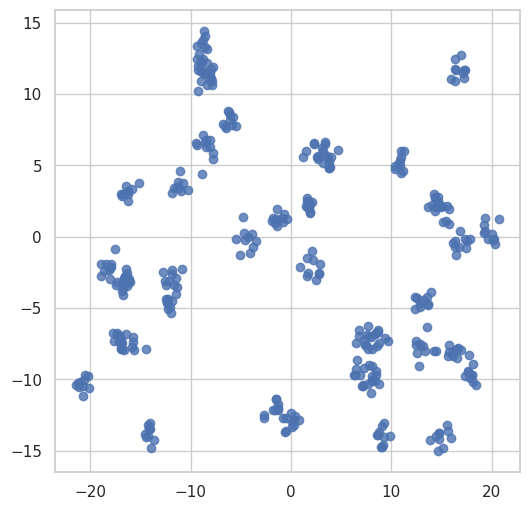

In [ ]:
from sklearn.datasets import make_blobs

X, Y = [(0, 0)], [0]

for n, random_state, std in zip([4, 40, 400], [9, 15, 55], [20, 5, 0.5]):
  X, Y = make_blobs(
    n_samples=n,
    centers=X,
    random_state=random_state,
    cluster_std=std
  )

X[:, 0] += 15
X[:, 1] += 5

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.8)
plt.show()

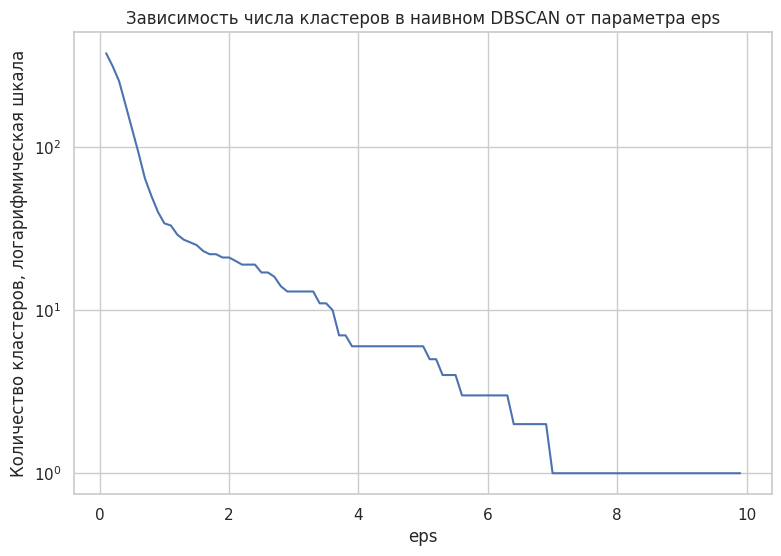

In [ ]:
from sklearn.cluster import DBSCAN

cnt = []
for eps in np.arange(0.1, 10, 0.1):
  model = DBSCAN(eps=eps, min_samples=1)
  clusters = model.fit_predict(X)
  cnt.append(int(np.max(clusters)) + 1)

plt.figure(figsize=(9, 6))
plt.semilogy(np.arange(0.1, 10, 0.1), cnt)
plt.title('Зависимость числа кластеров в наивном DBSCAN от параметра eps')
plt.xlabel('eps')
plt.ylabel('Количество кластеров, логарифмическая шкала')
plt.show()

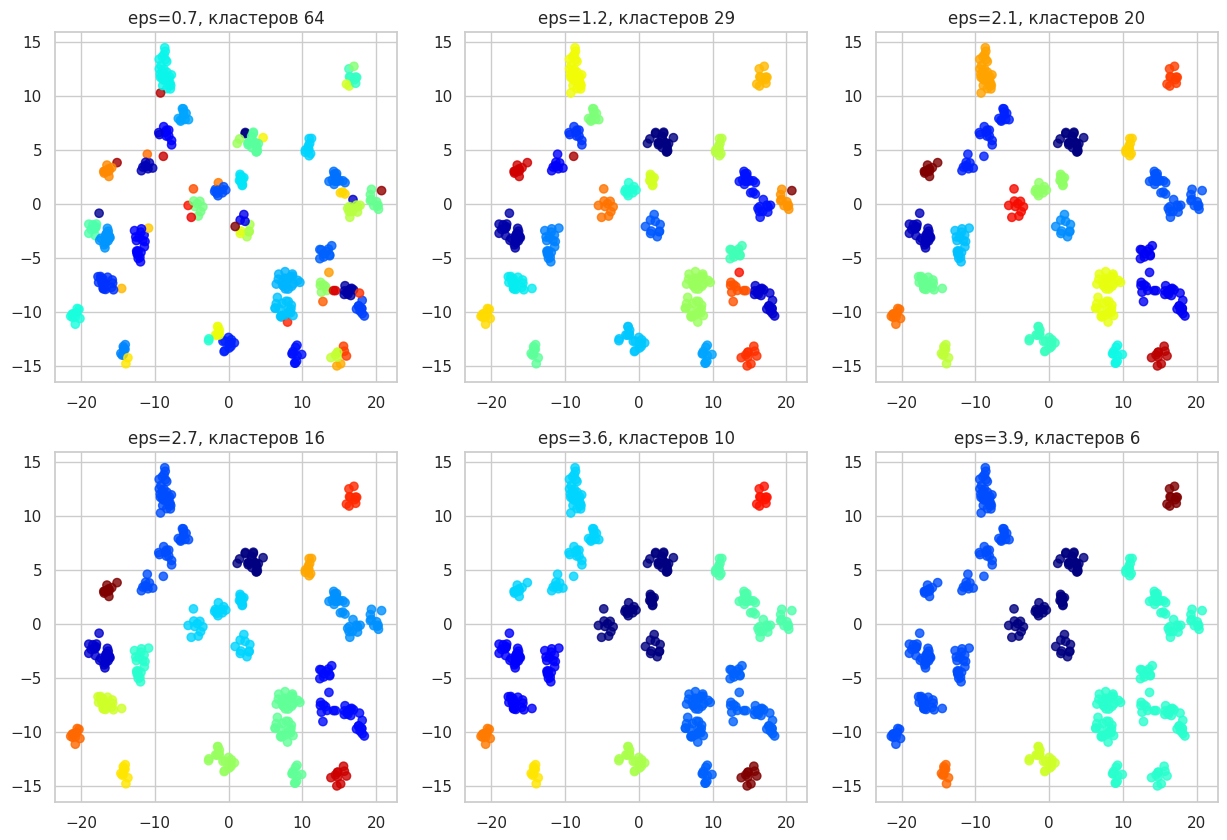

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, Y = [(0, 0)], [0]

for n, random_state, std in zip([4, 40, 400], [9, 15, 55], [20, 5, 0.5]):
  X, Y = make_blobs(
    n_samples=n,
    centers=X,
    random_state=random_state,
    cluster_std=std
  )

X[:, 0] += 15
X[:, 1] += 5

sizes = [64, 29, 20, 16, 10, 6, 0]
epses = []
partitions = []
for eps in np.arange(0.1, 10, 0.1):
  model = DBSCAN(eps=eps, min_samples=1)
  clusters = model.fit_predict(X)
  if int(np.max(clusters)) + 1 == sizes[len(epses)]:
    epses.append(eps)
    partitions.append(clusters)

plt.figure(figsize=(15, 10))
for i, (eps, c) in enumerate(zip(epses, partitions)):
    plt.subplot(2, 3, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=c, cmap="jet", alpha=0.8)
    plt.title(f'eps={eps:.1f}, кластеров {str(sizes[i])}')

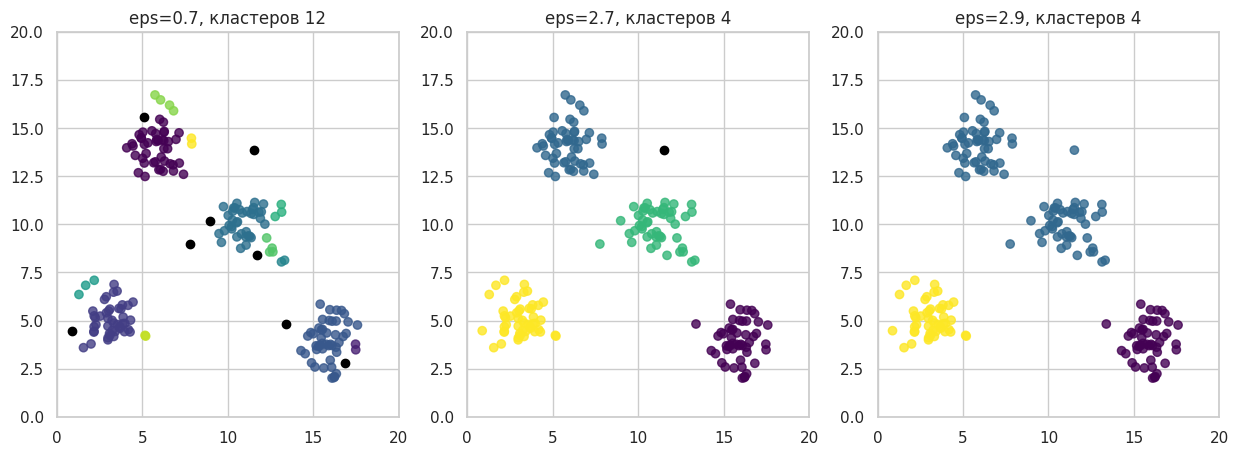

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, Y = make_blobs(
    n_samples=200,
    centers=[(16, 4), (6, 14), (11, 10), (3, 5)],
    random_state=42
)

plt.figure(figsize=(15, 5))
for i, eps in enumerate([0.7, 2.7, 2.9]):
    plt.subplot(1, 3, i + 1)
    model = DBSCAN(eps=eps, min_samples=2)
    c = model.fit_predict(X)
    if i > 0:
      p = np.array([1, 0, 3, 2])
      c[c != -1] = p[c[c != -1]]
    plt.scatter(X[c != -1, 0], X[c != -1, 1], c=c[c != -1], cmap="viridis", alpha=0.8)
    plt.scatter(X[c == -1, 0], X[c == -1, 1], c='black')
    plt.xlim(0, 20)
    plt.ylim(0, 20)
    plt.title(f'eps={eps:.1f}, кластеров {str(int(np.max(c)) + 1)}')

Как мы видим, параметр $𝜀$ связан с числом кластеров обратной зависимостью: чем больше $𝜀$, тем меньше кластеров, и наоборот. При этом если выбрать слишком маленькое значение, кластеры могут получаться крайне мелкими, а если чуть-чуть переборщить с $𝜀$, могут получиться один-два слишком больших кластера. Также сыграла свою роль точка наверху зелёного кластера: она так далеко от остальных, что если выбрать $𝜀$, покрывающий это расстояние, можно случайно дотянуться и до другого кластера (вообще, лучше $𝜀$ под эту точку не подгонять, так как она объективно является шумом). Получается, что $𝜀$ надо выбирать с умом (желательно пробовать разные варианты). При этом нет какого-то способа, как по датасету автоматически найти оптимальное значение $𝜀$. Вы можете подумать, что стоит просто выбрать требуемое число кластеров, а дальше перебором найти $𝜀$, при котором получается столько кластеров (можно даже оптимизировать такой перебор с помощью [бинарного поиска](https://wiki.algocode.ru/index.php?title=%D0%91%D0%B8%D0%BD%D0%B0%D1%80%D0%BD%D1%8B%D0%B9_%D0%BF%D0%BE%D0%B8%D1%81%D0%BA_%D1%81_%D0%B2%D0%B5%D1%89%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8_%D1%87%D0%B8%D1%81%D0%BB%D0%B0%D0%BC%D0%B8)). Но как в таком случае выбрать требуемое число кластеров?.. Что выбор $𝜀$, что выбор числа кластеров наперёд - задача совсем не очевидная. Поэтому всё, что здесь можно посоветовать, это брать разные значения и оценивать качество результата (осмысленность кластеров и т.п.) ручками (ну или метриками, о которых мы поговорим в конце этой статьи).

Такие параметры (в нашем случае $𝜀$, а у каких-то алгоритмов кластеризации это непосредственно число кластеров), которые влияют на результат работы алгоритма, но определяются до начала его работы (а удачность их выбора оценивается после получения результата) называются **гиперпараметрами**. И сейчас мы познакомимся с ещё одним из них.

### Плотность против шума

Давайте посмотрим на такой пример:

![Два кластера соеденены через несколько вершин между ними. Соседние вершины соеденены отрезками](5.png)

У нас проблема: в данных очевидно, есть два кластера, но из-за шума алгоритм соединяет их тоненьким мостиком. Очевидно, это не тот результат, который мы хотели бы. Что делать?

На самом деле, в DBSCAN эта проблема давно решена вводом второго параметра, который обычно называют **min_samples** или **min_points**. Этот параметр накладывает ещё одно условие на вершины кластера: на расстоянии $𝜀$ от вершины кластера должно быть не менее min_points вершин (включая эту вершину). Если же соседей слишком мало, но они есть, вершина добавляется в кластер, однако новые вершины (для которых она будет соседней) через неё добавляться уже не смогут. Более формально:

1) Изначально все вершины считаются независимыми и не принадлежат никакому кластеру
2) Выбираем любую независимую вершину, у которой в радиусе $𝜀$ хотя бы min_points вершин, объявляем её новым кластером, кладём эту вершину в очередь, в след за ней кладём всех её независимых соседей
3) Забираем первую вершину из очереди
4) Если у неё в радиусе $𝜀$ хотя бы min_points вершин, эта вершина объявляется **внутренней** вершиной кластера, все её независимые соседи добавляются в кластер и очередь (если ещё не)
5) Если же в радиусе $𝜀$ менее min_points вершин, эта вершина объявляется **граничной** вершиной кластера, в кластере она остаётся, но новых соседей не добавляет
6) Если очередь не пуста, выполняем пункт 3 снова
7) Если же очередь пуста, завершаем формирование этого кластера
8) Если есть ещё независимые вершины, у которых в радиусе $𝜀$ хотя бы min_points независимых вершин, начинаем формирование нового кластера с пункта 2
9) Завершаем алгоритм. Все оставшиеся независимые вершины объявляются шумом

Это и есть классический DBSCAN. Если присмотреться, можно понять, что до этого у нас алгоритм работал как с min_points равным 2. Если сделать min_points равным 1, алгоритм не будет отбраковывать шум, вместо этого он будет создавать кластеры из одно элемента. Если же сделать min_points очень большим (10 и больше), останутся только самые плотные кластеры. Под **плотностью** подразумевается то, на сколько много вершин находится на очень маленьком расстоянии друг от друга (по аналогии с плотностью вещества: когда газ переходит в жидкость или жидкость переходит в твёрдое состояние, молекулы начинают быть ближе друг к другу и растёт плотность, то есть количество вещества на единицу объёма). Чем выше min_points, тем более плотные кластеры ищет алгоритм.

Для решения нашей изначальной проблемы достаточно сделать min_points равным 4:

![Теперь у выделенной вершины в центре всего 3 соседа (включая её саму), поэтому она не может объединить кластеры в один](6.png)

### Особенности DBSCAN

Данный алгоритм работает отлично в одних ситуациях, но плохо в других:

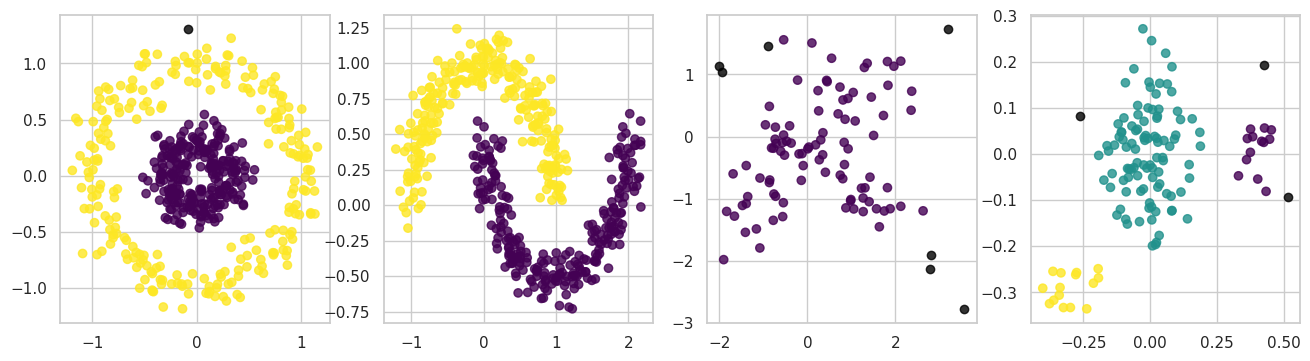

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification, make_blobs
from sklearn.cluster import DBSCAN

datasets = [
    make_circles(n_samples=500, noise=0.1, factor=0.3, random_state=42),
    make_moons(n_samples=500, noise=0.1, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0),
    make_blobs(n_samples=[100, 15, 15], centers=[(0, 0), (0.4, 0), (-0.3, -0.3)], cluster_std=[0.1, 0.05, 0.05], random_state=42)
]

plt.figure(figsize=(16, 4))
epses = [0.2, 0.2, 0.7, 0.1]
for i, eps in enumerate(epses):
    plt.subplot(1, 4, i + 1)
    model = DBSCAN(eps=eps, min_samples=4)
    c = model.fit_predict(datasets[i][0])
    plt.scatter(datasets[i][0][c != -1, 0], datasets[i][0][c != -1, 1], c=c[c != -1], cmap='viridis', alpha=0.8)
    plt.scatter(datasets[i][0][c == -1, 0], datasets[i][0][c == -1, 1], c='black', alpha=0.8)

В первых двух случая можно увидеть кое-что неочевидное: некоторые точки из одного кластера ближе к другому кластеру, чем друг к другу. Но это не баг, а фича. Данные же не случайно организованы именно в таком порядке. Если группа точек образует кольцо или параболу, значит они подвержены какой-то общей закономерности. И нам важнее объединить в один кластер точки, подверженные этой общей закономерности, а не просто точки, собранные максимально близко друг к другу. Именно здесь и пригождается плотность: DBSCAN идёт по плотно расположенным точкам вдоль всего кластера, даже если кластер вытянут в сложную фигуру.

А вот в третьем примере, где, как вы помните, три кластера сильно переплетены, наш алгоритм не справляется, обобщая всё в один кластер. Поэтому для разных ситуаций существуют разные [алгоритмы](https://scikit-learn.org/stable/modules/clustering.html). Например, часто используемый алгоритм **k-means** мог бы справиться с третей картинкой (но не идеально), если ему изначально сказать, сколько нужно кластеров ($k=3$, а вот DBSCAN количество кластеров указывать не нужно). Однако зато он не справился бы с последней картинкой, так как начал бы бить самый крупный кластер на три части, относя два остальных кластера к каким-то из них. Причина такого разного поведения в том, что k-means минимизирует **внутрикластерное расстояние** (среднее расстояние между точками в кластере), делая кластеры маленькими по занимаемой площади, в то время как DBSCAN максимизирует расстояние между кластерами, поэтому он лучше всего подходит для тех датасетов, где между плотными кластерами есть чёткие "пробелы" или слабые "мостики", как в предыдущем пункте.

Наглядно илюстрирует разность следующий пример:

Text(0.5, 1.0, 'Кластеризация через KMeans')

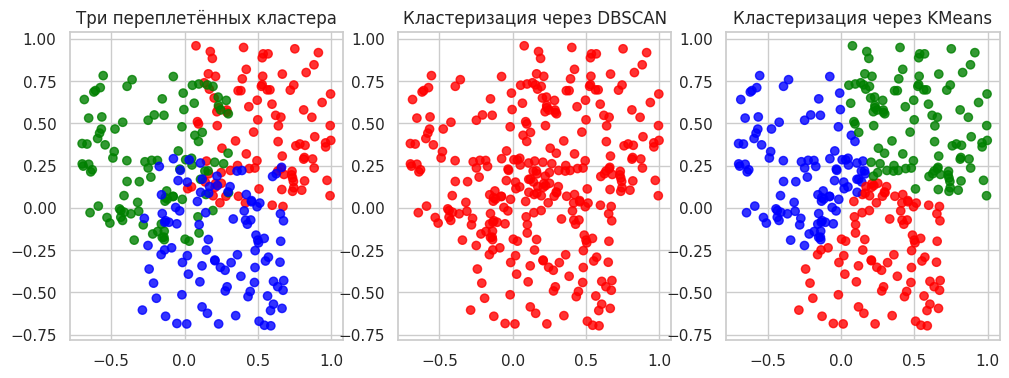

In [ ]:
from sklearn.cluster import DBSCAN, KMeans

X = []
for x0, y0, sz in [(0, 0, 100), (-0.7, -0.2, 100), (-0.3, -0.7, 100)]:
  x = np.random.rand(sz)
  y = np.random.rand(sz)
  cluster = np.column_stack((x, y))
  cluster[:, 0] += x0
  cluster[:, 1] += y0
  X.append(cluster)
X = np.vstack(X)

def num_to_color(c):
  c = list(c)
  c = [int(e) for e in c]
  for num, color in enumerate(['red', 'green', 'blue']):
    c = [color if e == num else e for e in c]
  return c

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
c = [0] * 100 + [1] * 100 + [2] * 100
plt.scatter(X[:, 0], X[:, 1], c=num_to_color(c), alpha=0.8)
plt.title('Три переплетённых кластера')

model = DBSCAN(eps=0.2, min_samples=4)
c = model.fit_predict(X)
plt.subplot(1, 3, 2)
plt.scatter(X[c != -1, 0], X[c != -1, 1], c=num_to_color(c[c != -1]), alpha=0.8)
plt.scatter(X[c == -1, 0], X[c == -1, 1], c='black', alpha=0.8)
plt.title('Кластеризация через DBSCAN')

model = KMeans(n_clusters=3)
c = model.fit_predict(X)
plt.subplot(1, 3, 3)
plt.scatter(X[c != -1, 0], X[c != -1, 1], c=num_to_color(c[c != -1]), alpha=0.8)
plt.scatter(X[c == -1, 0], X[c == -1, 1], c='black', alpha=0.8)
plt.title('Кластеризация через KMeans')

Все эти примеры уже добавлены в наш визуализатор.

## 4. Метрики расстояния между объектами

Предположим, что мы решили кластеризовать пиксели на какой-то картинке по цвету, чтобы получить палитру её цветов.

Рассмотрим вот такой пример из пикселей трёх цветов (для простоты вызуализации будем работать не с RGB, а только с красным и зелёным каналом, синих оттенков в примере не будет)

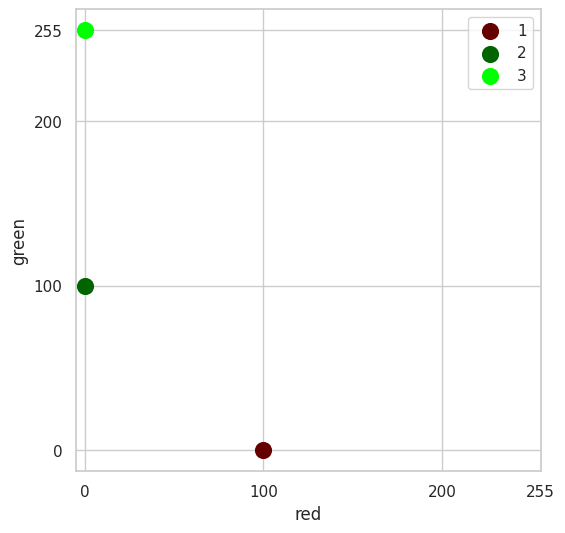

In [ ]:
plt.figure(figsize=(6, 6))
for i, (x, y, c) in enumerate([(100, 0, '#640000'), (0, 100, '#006400'), (0, 255, '#00FF00')]):
  plt.scatter(x, y, c=c, s=128, label=str(i + 1))
plt.xticks([0, 100, 200, 255])
plt.yticks([0, 100, 200, 255])
plt.legend()
plt.xlabel('red')
plt.ylabel('green')
plt.show()

Расстояние между первыми двумя точками (считаем по теореме Пифагора, как и раньше) равно $100 \sqrt{2} \approx 141$, что меньше расстояния между второй и третей точкой, равного $155$. Получается что-то странное. Первая и вторая точка с большей вероятностью окажутся в одном кластере, и это критично, ведь когда мы посчитаем их среднее (чтобы каждый кластер был представлен в палитре одним цветом), получится тёмно-серый цвет (точка с координатами $(50, 50)$), не передающий никакой реальной информации. При этом очевидно, что было бы логичней объединить в один кластер две зелёные точки.

Проблема вызвана особенностями нашей формулы $\sqrt{Δx^2 + Δy^2}$ для расстояний. Она из-за своих особенностей оценивает расстояние при изменении обоих координат более "лояльно", чем когда меняется расстояние только по одной координате. Поэтому изменяя обе координаты на $100$ мы получаем меньшее расстояние, чем меняя одну координату на $155$. Но согласитесь, очень странное решение считать расстояние между разными цветами в RGB по вот такой формуле, возводя в квадрат и извлекая корень. Как это вообще связано с цветами? Как видно из примера выше, связано плохо... Есть ли какой-то другой способ определять расстояние?

### Манхэттенское расстояние

Да, такой способ есть (и даже не один). Давайте вместо сложной формулы просто скажем, что расстояние между двумя цветами - это сумма разностей их красного, зелёного и синего каналов. Например, наши цвета $(100, 0, 0)$ (тёмно-красный, теперь я записал и синий канала) и $(0, 100, 0)$ (тёмно-зелёный) отличаются на $100$ по красному каналу, на $100$ по зелёному и на $0$ по синему. В сумме получаем $100 + 100 + 0 = 200$. Это и будем считать расстоянием между цветами. Расстояние же между второй и третей (с координатами $(0, 255, 0)$) точкой на нашей картинке будет равно $155 < 200$, так как отличаются они только по зелёному каналу.

Таким образом формула расстояни теперь $|Δx| + |Δy| + |Δz|$. Модуль здесь нужен для того, чтобы было не важно, в какую сторону (большую или меньшую) отличаются координаты. Инача расстояние между, к примеру, точками $(2, 1, 0)$ и $(1, 2, 0)$ было бы равно $(2-1) + (1-2) + (0-0) = 1 - 1 + 0 = 0$, что было бы странно.

Такое расстояние называется **Манхэттенское** и оно было названо в честь острова в Нью-Йорке, на котором улицы расположены строго под прямыми углами, образуя сетку как в третради в клетку. Чтобы перемещаться по такому району, нужно сначала идти вертикально, а потом горизонтально, меняя своии координаты по очереди, поэтому суммарный маршрут образуется сложением разности координат (не как если бы можно было срезать, идя по диагонали). Формула легко обобщается на любое число координат: берём модули разности координат по каждой оси и складываем.

Свойства у Манхэттенского расстояния совершенно не такие, как у **Евклидова** (так называется наше изначальное расстояние через теорему Пифагора). Посмотрим на такой пример:

Text(0.5, 1.0, 'Манхэттенское расстояние, eps=1')

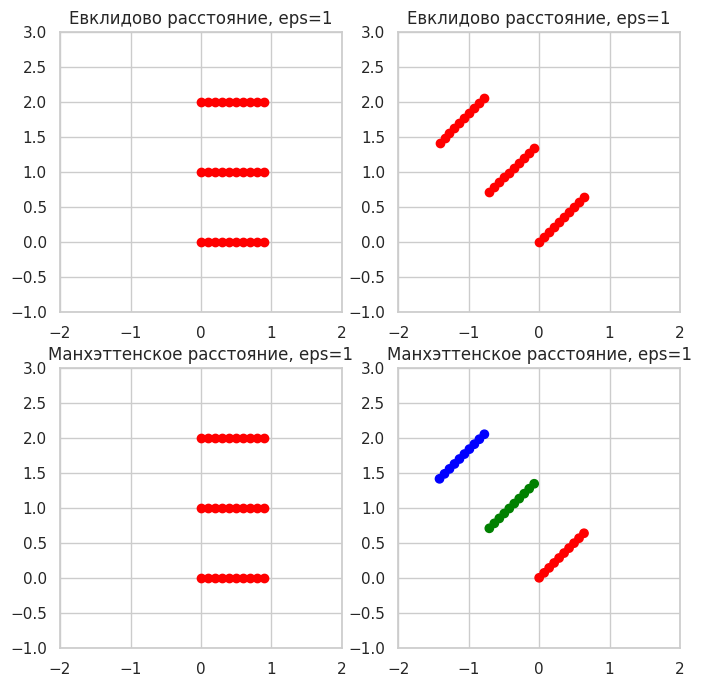

In [ ]:
N = 10
x = np.arange(0, N) / N
x = np.tile(x, 3)
y = np.array([0, 1, 2])
y = np.repeat(y, N)

def num_to_color(c):
  c = list(c)
  c = [int(e) for e in c]
  for num, color in enumerate(['red', 'green', 'blue']):
    c = [color if e == num else e for e in c]
  return c

xr = x / np.sqrt(2) - y / np.sqrt(2)
yr = x / np.sqrt(2) + y / np.sqrt(2)

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.scatter(x, y, c='red')
plt.xlim(-2, 2)
plt.ylim(-1, 3)
plt.title('Евклидово расстояние, eps=1')

plt.subplot(2, 2, 2)
plt.scatter(xr, yr, c='red')
plt.xlim(-2, 2)
plt.ylim(-1, 3)
plt.title('Евклидово расстояние, eps=1')

plt.subplot(2, 2, 3)
plt.scatter(x, y, c='red')
plt.xlim(-2, 2)
plt.ylim(-1, 3)
plt.title('Манхэттенское расстояние, eps=1')

plt.subplot(2, 2, 4)
plt.scatter(xr, yr, c=num_to_color(y))
plt.xlim(-2, 2)
plt.ylim(-1, 3)
plt.title('Манхэттенское расстояние, eps=1')

То есть если повернуть датасет на 45 градусов, Евклидово расстояние не меняется, а вот Манхэттенское увеличивается, так как теперь ненулевые обе координаты. Манхэттенскому не всё равно на соотношение между координатами, в то время как Евклидово поощряет расстояние "по диагонали".

![Разница между поведением Евклидовой и Манхэттенской метрик (для наглядности eps = 105 пикселям). Область поиска с радиусом eps у Манхэттенской похожа на ромб](7.png)

Манхэттенское расстояние логично применять и в других случаях. Например, пусть мы кластеризуем студентов по набору их учебных курсов. Каждый студент будет массивом из 0 и 1: $i$-ый элемент равен 1, если студент прошёл $i$-ый учебный курс, и 0 иначе. И здесь тоже логично считать расстояние (степень "непохожести") между студентами как количество курсов, по которым их статус различен (один прошёл, другой не прошёл). И это, если присмотреться, тоже Манхэттенское расстояние: разницы $0 - 0$ и $1 - 1$ (оба прошли/не прошли) ничего не дают к общей сумме, а остальные курсы добавляют $|1-0|=|0-1|=1$ к расстоянию. Согласитель, хорошая и логичная метрика для этой задачи. Лучше, чем извлекать квадратный корень.

Манхэттенское расстояние часто применяют для задач, где мы работает с 0 и 1 (есть/нет объект), а промежуточных состояний нет или они нежелательны. Вот, например, применение к шуму в задаче томографии (хотим, чтобы шум был как можно ближе к 0, то есть к чёрным пикселям): хотим восстановить изображение (первая картинка), но получается результат с сильными помехами (вторая картинка), нагладываем ограничение к помехам, заставляя быть ближе в Евклидовом понимании к чёрному фону (третья картинка), но лучше становится при перехоже к Манхэттенской метрике (четвёртая картинка). Этот подход называется [регуляризацией](https://ru.wikipedia.org/wiki/%D0%A0%D0%B5%D0%B3%D1%83%D0%BB%D1%8F%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_(%D0%BC%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D0%BA%D0%B0)).

![Задача томографии с разными типами регуляризации: оригинал, решение без регуляризации, с Евклидовой (L2), с Манхэттенской (L1)](10.png)

### Расстояние Чебышёва

Однако что если мы, к примеру, сравниваем не 0 и 1, а какие-то характеристики объектов, и нам не требуется при оценке расстояния складывать (или как-то ещё "суммировать") разницу по всем характеристикам? Например, если у нас есть персонажи компьютерной игры, у которых есть характеристики "сила", "ловкость", "интеллект" и т.д. (каждая по шкале от 0 до 100), мы понимаем, что персонажи, у которых по каждой характеристике отличие максимум на 1 единицу, будут вести себя похоже, и нам не важно, отличаются они на 1 по одной характеристике, или на 1 по всем 50 характеристикам. Тактика всё равно будет +- идентичной. А вот если персонажи похожи по всем характеристикам, а по одной отличаются на 50 единиц, это куда более существенное отличие. В Манхэттенском расстоянии оба случая считались бы одинаковыми (расстояние было бы 50), но здесь нам лучше оценивать расстояние как разницу в значении характеристик, по которым персонажи отличаются сильнее всего.

Это называется расстоянием Чебышёва. Его формула это $max(Δx, Δy, Δz)$, то есть максимум из разницы координат по всем осям. С точки зрения расстояния Чебышёва точки $(1, 1, 1)$ и $(1, 0, 0)$ находятся от точки $(0, 0, 0)$ на одинаковом расстоянии $=1$. Как и предыдущие расстояние, это обобщается на любую размерность.

У него тоже есть свои особенности. В отличии от Манхэттенского, оно поощряет разницу по всем координатам:

Text(0.5, 1.0, 'Расстояние Чебышёва, eps=0.8')

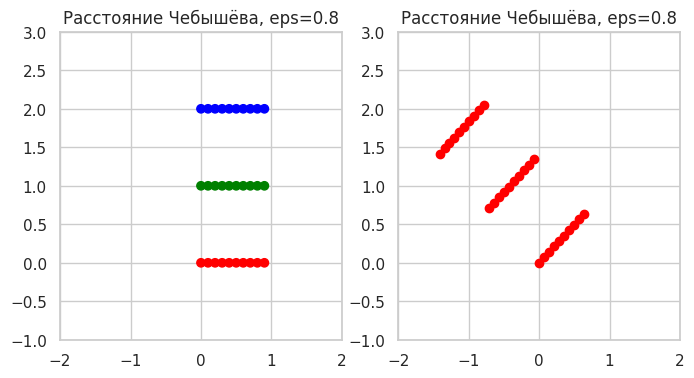

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.scatter(x, y, c=num_to_color(y))
plt.xlim(-2, 2)
plt.ylim(-1, 3)
plt.title('Расстояние Чебышёва, eps=0.8')

plt.subplot(1, 2, 2)
plt.scatter(xr, yr, c='red')
plt.xlim(-2, 2)
plt.ylim(-1, 3)
plt.title('Расстояние Чебышёва, eps=0.8')

![Как оценивает расстояние метрика Чебышёва. Здесь eps = 80 пикселей. Зона поиска похожа на квадрат](8.png)

### L_p метрики и другие расстояния

А в чём же тогда смысл Евклидового расстояния? Помимо каких-то данных с геометрическим смыслом, оно часто принимается как "компромиссный" вариант, когда мы не хотим поощрят изменение сразу по всем координатам, как это делает расстояние Чебышёва. Также у Евклидовой метрики есть некоторые интересные с точки зрения математического анализа свойства, которые полезны в машинном обучении и других прикладных сферах.

Для регулирования "компромиссности" существует обобщение расстояний в $L_p$ метрику. Его формула выглядит так:

$$\sqrt[p]{|Δx|^p + |Δy|^p + |Δz|^p}$$

Конкретная формула задаётся выбором константы $p \geq 1$. Нетрудно заметить, что при $p=2$ получается формула Евклидова расстояния, а при $p=1$ формула Манхэттенского. Пытливый читатель может подумать, почему при $p \to \infty$ получается расстояние Чебышёва. Посмотрим на изменение окружности радиуса 1 при разных $p$:

![Видно, что при p, стремящемся к бесконечности, окружность превращается в квадрат](9.png)

И даже это не все метрики, которые существуют. Бывают, например, косинусные расстояния, для которых важны углы. А какой-нибудь сложно устроенный город лучше всего задачь через карту в виде взвешенного графа из разных адресов, где расстояния считаются как навигаторе. Существует даже [редакторское расстояние](https://ru.wikipedia.org/wiki/%D0%A0%D0%B0%D1%81%D1%81%D1%82%D0%BE%D1%8F%D0%BD%D0%B8%D0%B5_%D0%9B%D0%B5%D0%B2%D0%B5%D0%BD%D1%88%D1%82%D0%B5%D0%B9%D0%BD%D0%B0), измеряющее разницу между словами: чем больше букв надо поменять в слове A, чтобы получить слово B, тем больше расстояние.

Придумать можно что угодно, конкретная метрика всегда зависит от данных и наших целей. Главное, что любое расстояние должно удовлетворять трём в полне логичным свойствам:

1) Расстояние между любыми двумя объектами должно быть неотрицательным, причём равняться нулю оно может (и должно) только если объекты одинаковы (имеют одинаковые координаты/характеристики)

2) Расстояние между любыми объектами A и B должно быть равно расстоянию между объектами B и A (одинаковое расстояние в обе стороны)

3) Расстояние между любыми объектами A и B должно быть не больше, чем сумма расстояний между объектами A и C и объектами C и B (C любое)

Последнее правило называется **неравенством треугольника**. В школе проходят его частный случай: в любом треугольнике сумма длин любых двух сторон больше третей стороны. Именно из-за неравенства треугольника нельзя брать $p < 1$ в $L_p$ метриках. Оно просто перестанет выполняться.